# Multi Agent Systems: A3 - Single Agent Search
#### Deadline: 07-05-2026, 12:00 (Noon!)

You may hand in the assignment up to a day late, in which case the assignment grade will be capped at 8. For any extensions please contact the TAs.

Hand in the notebook file on Brightspace, name your file as follows: $\textbf{A3\_yourname.ipynb}$

Studentname: Ella Kemperman \
Studentnumber:  s1119890


$\textit{Don't forget to label your axis and give your graphs titles!}$

### AI Disclaimer

There is no need to use AI such as LLM based chatbots in the assignments (unless
explicitly said otherwise). While the use of AI is not forbidden, whenever AI is used,
you are expected to report what model was used, where was it used in the assignment,
how, and for what purpose. Use the cell below to summarise your AI use. 

**Also note it if you did not use AI! If so, we expect to see absolutely no signs of AI use in your assignment.**

---
#### FILL THIS IN
**Did you use AI for this assignment?** No

---

## Part 1 - ***MIPS from the Continuity Equation*** (1.5 points)

We consider a system of agents/particles which are spread over an area with density $c(x,t)$ and flux:

$\vec J(c) = c \, \vec v(c)$

where:
- $c(x,t)$: local density (how many particles per volume)
- $\vec v(c)$: density-dependent speed (decreasing function of density)
- $\vec J(c)$: particle flux (how particles move through space)

The density evolves according to the continuity equation:
$$\partial_t c + \vec \nabla \cdot \vec J = 0$$
- $\partial_t c$: change of density in time
- $\vec \nabla $: spatial gradients (of particle flow) in and out of a region. In 1D: $\vec \nabla \rightarrow \partial_x$.

Reproduce the condition for collective aggregatoin of moving agents (in 1D is enough): Start from the continuity equation, fill in $\vec J$, use the chain rule to expand $\vec \nabla \cdot \vec J$, and derive the condition for MIPS to occur, so find when small density variations grow instead of smooth out.

Filling in $\mathbf{J}(c)$ and assuming 1D yields:
$$\frac{\partial c}{\partial t} = -\frac{\partial}{\partial x} c(x, t)v(c(x, t))$$
Rewriting using product rule:
$$\frac{\partial c}{\partial t} = -\frac{\partial c(x, t)}{\partial x} v(c(x, t)) -\frac{\partial v(c(x, t))}{\partial x} c(x, t)$$
Using chain rule:
$$\frac{\partial c}{\partial t} = -\frac{\partial c(x, t)}{\partial x} v(c(x, t)) -\frac{\partial v(c)}{\partial c}\frac{\partial c(x, t)}{\partial x} c(x, t)$$
Factoring out $\frac{\partial c(x, t)}{\partial x}$
$$\frac{\partial c}{\partial t} = -\frac{\partial c(x, t)}{\partial x}\left(v(c(x, t)) +\frac{\partial v(c)}{\partial c}c(x, t)\right)$$

As speed is stated to decrease with concentration, $\frac{\partial v(c)}{\partial c}$ will be negative at a point where MIPS occurs, as when MIPS occurs, the concentration is only increasing at a point. Furthermore, $c(x, t)$ will always be positive, as a negative concentration is not a thing. Therefore, for the concentration to be increasing over time at a spot, i.e. $\frac{\partial c}{\partial t} \geq 0$, at points where $\frac{\partial c(x, t)}{\partial x}$ is positive (e.g. slightly left to a point where MIPS occurs), the speed $v(c(x, t))$ needs to satisfy $v(c(x, t)) + \frac{\partial v(c)}{\partial c}c(x, t) \geq 0$. For a point where $\frac{\partial c(x, t)}{\partial x} < 0$, then $v(c(x, t)) + \frac{\partial v(c)}{\partial c}c(x, t) \leq 0$.

## Part 2 - Multiagent search of lost targets 2D in a static world using range sensors (I)

**Author**: Pablo Lanillos Donders Institute 2022-03-01 \
**Adapted by**: Luco Buise & Matan Yah Ben Zion 2024-04-24

### Description of the problem

<br/>

<img src="img/problem-definition.png" width="400" style="float: left; padding: 10px" />
Moving beyond rudimentary, stochastic agents, we will now start to look at more intelligent agents, that have a probabilistic internal representation of the world around them. Initially, we will look at simple non-communicating agents, and evolve into cooperative swarm that employs communication.

This assignment serves as a set up for the next three assignments. We will slowly build up to program an algorithm that lets multiple searching agents find survivors in an environment as soon as possible. In a real life scenario, the algorithm could for example compute the optimal actions for Unmanned Aerial Vehicles.

The assignment .zip file also contains the **numpy_plt_basics.ipynb** notebook. This file contains examples and explanation for several numpy and matplotlib functions that you will need in this assignment. You should be familair with most of the topics covered in the notebook, but it could definitely help you refresh your memory and guide you when you might get stuck.

*In this notebook*

    a) Introducing the problem: environment, agent and sensor 
    b) One agent search greedy 1 step discrete

*In the following assignments*

1. Multiagent search greedy 1 step discrete no communication
2. Multiagent search greedy 1 step discrete common belief
3. Multiagent search n-step continuous optimization (centralized)
4. Multiagent search with camera sensor

**References**: 
- Lanillos, P. (2013): Minimum time search of moving targets in uncertain environments. Ph.D. Dissertation. url: 
http://www.therobotdecision.com/papers/PhD_MinimumTimeSearch_2013_FinalElectronic_English_PabloLanillos.pdf

*Continuous*
- Lanillos, P., Gan, S. K., Besada-Portas, E., Pajares, G., & Sukkarieh, S. (2014). Multi-UAV target search using decentralized gradient-based negotiation with expected observation. Information Sciences, 282, 92-110.

*Discrete*
- Lanillos, P., Besada-Portas, E., Pajares, G., & Ruz, J. J. (2012, October). Minimum time search for lost targets using cross entropy optimization. In 2012 IEEE/RSJ International Conference on Intelligent Robots and Systems (pp. 602-609). IEEE.


### Description of the problem



There is a shipwreck alert. We need to find the survivors but we do not have so much time. We count with a fleet of Unmanned Air Vehicles (UAVs) with sensors on board. We also have an initial guess of the possible areas where the survivors can be, such as a probability of finding the survivors. For simplicity we are going to do a strong assumption: the location of the survivors is constant. In other words, the world is static or the targets (survivors) do not have dynamics.

**The goal of this assignment is to program an algorithm that let multiple searching agents to find the survivors as soon as possible.** In other words, the algorithm should compute the optimal actions for the UAVs.

<img src="img/shipwreck.png" width="600"  style = " padding: 10px"/>

### Import needed libraries

In [1]:
# Numpy numerical library -> import [library] as name
import numpy as np

# Plotting libraries -> matplotlib
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D # 3D plots
from matplotlib import cm # Color maps

# Matrix auxiliary functions
import numpy.matlib

# System libraries
import os
import sys

### a) Introducing the problem: environment, sensor and agents

#### Environment (0.5 points)
We model the environment as bounded 2D space of width $w$ and height $h$. The discrete representation of the world can be stored in a matrix that looks like:

<img src="./img/map.png" width="400" />


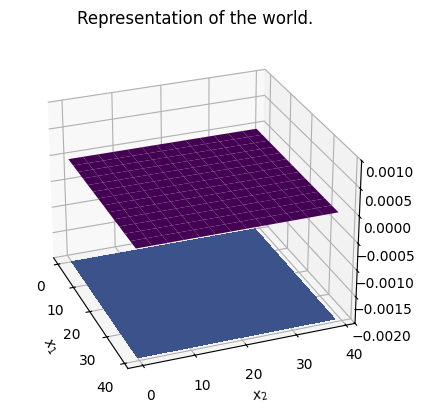

In [2]:
# Plot the discrete environment
width = height = 40 # Size of the environment

x = y = np.arange(0, width) # This only works if both have the same size
X, Y = np.meshgrid(x, y) # generate grid
map = np.zeros((width,height))

# Write your code here for plotting the map using plot_surface (see numpy_plt_basics notebook)
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, map, rstride=3, cstride=3, linewidth=1, antialiased=True, cmap=cm.viridis)
cset = ax.contourf(X, Y, map, zdir='z', offset=-0.002, cmap=cm.viridis)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Representation of the world.")
# Adjust the limits, ticks and view angle
ax.set_zlim(-0.002,0.001)
ax.view_init(27, -21)
plt.show()

#### Sensor (1 point)

Each agent $i$ has a range sensor on board able to detect people in the sea with probability $p$. The position of the agent  is $x=\{x_i,x_j\}$ (2D location). We are going to model the sensor in a probabilistic fashion. The sensor will return the probability of non-detecting the target. This is due to the utility function that we will see afterwards. Given the euclidean distance between the agent and the potential target location as $d$, the range sensor is modelled by the following equation:

$$p(\overline{D}) = 1 - P_{d_{max}} \exp\left[ -\sigma \left( \frac{d}{d_{max}}\right)^2 \right]$$

Note that we can compute the euclidian distance as $d = \sqrt{ (i-x_i)^2 +(j-x_j)^2}$ and $\exp$ is the exponential operator. The sensor can be thought of the following way: If the target is EXACTLY where the UAV is, the probability of the sensor NOT locating it is 0

$$p(\overline{D}|d=0) = 0$$

(in other words, if the UAV is exactly on the target it definitely finds it). This probablity decreases exponentialy as the UAV moves away from the target.

Program and plot the non-detection sensor model. The plot should looks like this one:

<img src="./img/pnd-sensor.png" width="400" />

Note that we can update the belief that the agent has about the world with observations using a Recursive Bayesian Estimator procedure. Here as the world is static we only need the update and not the prediction step.

The update for $N$ observations (N steps ahead) is as follows: 

$$ b^k = \left[\prod_{j=1}^N P(\overline D^{k+j} | x^{k+j}, \tau)\right] b^{k-1} $$

Where $b^{k-1}$ is our prior belief of the target location $P(\tau)$ and $N$ is the number of observations, and $j$ index is the number of steps ahead in the trajectory. Here, we are assuming independence of the measures (observations).


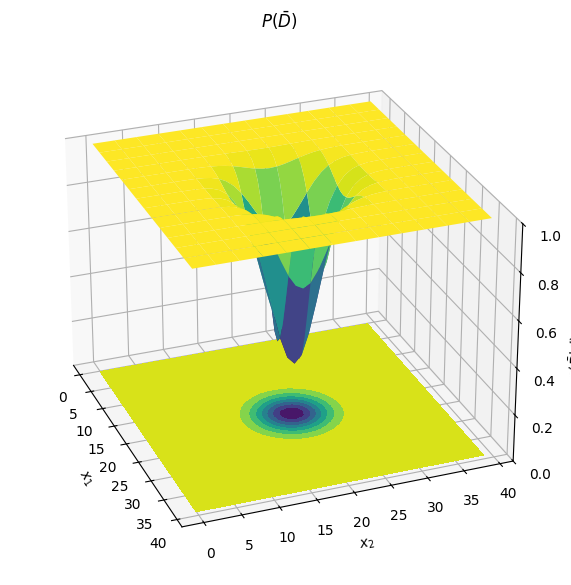

In [3]:
# observation model
Pdmax = 0.8 # Max range sensor
dmax = 4 # Max distance
sigma = 0.7 # Sensor spread (standard deviation)

x = np.array([20,20]) # Agent 2D location 
I = X.flatten() # Convert matrix into a single vector useful for operating 
J = Y.flatten() # Convert matrix into a single vector useful for operating 

## Write your code here
# Compute the sensor P(\overline{D}) with a function with name 
def sensor_pnd(agent_coords: np.ndarray, target_coords: np.ndarray = x, Pdmax: float = Pdmax, dmax: float = dmax, sigma: float = sigma):
    d = np.sum((agent_coords - target_coords)**2)**0.5
    return 1 - Pdmax * np.exp(-sigma * (d / dmax)**2)

# Plot the sensor
P = np.vectorize(lambda x, y: sensor_pnd(np.array([x, y])))(X, Y)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, P, rstride=3, cstride=3, linewidth=1, antialiased=True, cmap=cm.viridis)
cset = ax.contourf(X, Y, P, zdir='z', offset=-0.002, cmap=cm.viridis)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$p(\bar{D}|d)$")
ax.set_title(r"$P(\bar{D})$")
# Adjust the limits, ticks and view angle
ax.set_zlim(0, 1)
ax.view_init(27, -21)
plt.show()

#### Agents (1 point)
Each agent in the discrete version has its state defined as the 2D location $s$ at time $k$ ($s^k$) and a set of possible actions $u^k$. The grid and the possible actions are defined in the following figure:

<img src="./img/actions-discrete.png" width="400" />

In [4]:
ndir = 9 # number of movements
delta = 0.5 # Constant displacement
# Define the 9 possible movements with an array of size(ndir,2) of delta increments
# Example to move up is -delta, 0

# Write your code here
mat = np.array([
    [0, 0],
    [0, delta],
    [delta, 0],
    [0, -delta],
    [-delta, 0],
    [delta, delta],
    [delta, -delta],
    [-delta, delta],
    [-delta, -delta]
])


print("Movements\n", mat)


# Given the state of the agent
x = np.array([20,20])  # agent state

# Write a function that computes all next movements or forward states (fs) using the np.random.permutation function 
# We use this randomization to avoid selecting the same action when all actions have the same utility
# Write the code of the function here
def forward_states(agent_coords: np.ndarray, directions: np.ndarray = mat, width: int = width, height: int = height):
    randomised = np.random.permutation(directions)
    fs = randomised + agent_coords
    return fs[np.logical_and(np.logical_and(0 < fs[:, 0], fs[:, 0] < width), np.logical_and(0 < fs[:, 1], fs[:, 1] < height))]
    
fs = forward_states(x)

print("Forward states\n", fs)


Movements
 [[ 0.   0. ]
 [ 0.   0.5]
 [ 0.5  0. ]
 [ 0.  -0.5]
 [-0.5  0. ]
 [ 0.5  0.5]
 [ 0.5 -0.5]
 [-0.5  0.5]
 [-0.5 -0.5]]
Forward states
 [[19.5 20.5]
 [20.  20. ]
 [20.  20.5]
 [20.  19.5]
 [20.5 20.5]
 [19.5 19.5]
 [19.5 20. ]
 [20.5 20. ]
 [20.5 19.5]]


### Initial belief (prior information) (1 point)

Our intel department has computed that the shipwreck is in the middle of our environment: $w/2, h/2$. We model the initial probability of the target location $P(\tau)$ with a bivariate Gaussian distribution $N(\mu, \Sigma)$ like the following:

<img src="./img/b0.png" width="400" />


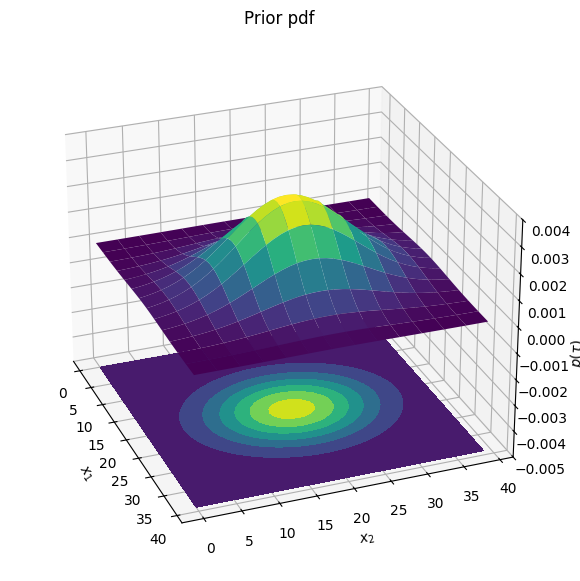

In [5]:
# Compute the initial prior belief for the agent
w = h = 40 # Size of the world
mu = np.array([w/2., h/2.])# center point
Sigma = np.array([[40,0],[0,60]]) # Bimodal covariance with no dependence.

# Write your code here for computing the bivariate Gaussian function 
# Tip: You should normalize the belief to sum to 1. You can divide the belief by its sum to obtain it
def bivariate_gaussian(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray):
    p = (2 * np.pi)**(-sigma.shape[0] / 2) * np.linalg.det(sigma)**(-0.5) * np.exp(-0.5 * (x - mu).T @ np.linalg.inv(sigma) @ (x - mu))
    return p

# Plot the sensor
P = np.vectorize(lambda x, y: bivariate_gaussian(np.array([x, y]), mu, Sigma))(X, Y)
P = P

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, P, rstride=3, cstride=3, linewidth=1, antialiased=True, cmap=cm.viridis)
cset = ax.contourf(X, Y, P, zdir='z', offset=-0.005, cmap=cm.viridis)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$p(\tau)$")
ax.set_title("Prior pdf")
# Adjust the limits, ticks and view angle
ax.set_zlim(-0.005, 0.004)
ax.view_init(27, -21)
plt.show()
# Plot the initial belief

### B) One agent search greedy 1 step discrete

We will program one agent search algorithm with 1-step ahead discrete (greedy). The idea is to select the next state that maximize the utility function: to maximize the probability of finding the target.

**Tip: This is the same as maximizing the (1- probability of not finding the target)**

The algorithm is as follows:
1. Compute the possible next states
2. Compute the utility for each new state
3. Select the maximum utility state $\arg \max$
4. Move the agent and perform an observation
5. Go to step 1

#### Utility function (2 points)

To evaluate "how good" is a state we compute how much information gain we accumulate we exerting an action. That is, an action $u$ is better if the probability of finding the target $\tau$ is higher than others. As we have deterministic actions: an action always arrives to the same state, we can model the utility function given the state $x$ as:

$$ U(x) =  \sum_\tau \left[ p(\overline{D}| x^k,\tau)  b_\tau^{k-1}\right]$$

This is the sum over all possible states of $\tau$ (marginalization) of the probability of non-detecting the target given the agent state and the target state.

Solving the problem is minimizing $U(x)$ or we can solve the maximization of $1-U(x)$.

In [6]:
# Program the utility computation for all possible forward states (using the previous agent code and prior initialization)
# You need to program the utility function and the function that returns the next best state

def utility(x: np.ndarray, prior: np.ndarray, grid: tuple[np.ndarray, np.ndarray] = (X, Y)):
    p_d = np.vectorize(lambda tau_x, tau_y: sensor_pnd(x, target_coords=np.array([tau_x, tau_y])))(grid[0], grid[1])
    return np.sum(p_d * prior)


def next_best_state(current_state: np.ndarray, prior: np.ndarray):
    next_states = forward_states(current_state)
    utilities = np.vectorize(lambda next_state: utility(next_state, prior), signature="(m) -> ()")(next_states)
    return next_states[np.argmin(utilities)]


xf = next_best_state(x, np.vectorize(lambda x, y: bivariate_gaussian(np.array([x, y]), mu, Sigma))(X, Y))
print("best state", xf)

best state [20. 20.]


### Algorithm (3 points)

Write the full algorithm with a loop. Plot the agent trajectory as well as the belief map as in this figure:

<img src="./img/solution.png" width="400" />

-------------------------------------------------

> One agent search 2D (greedy 1-step ahead)



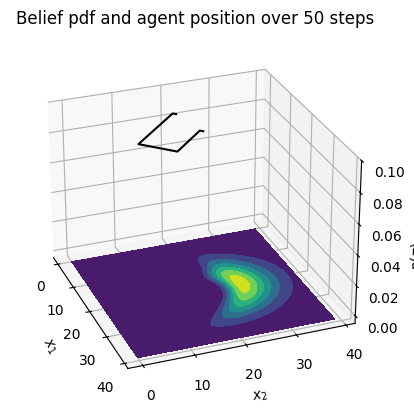

In [8]:
# Initialize variables and parameters
print('-------------------------------------------------\n');
print('> One agent search 2D (greedy 1-step ahead)\n')

# Initialize Agent
agent_pos = np.array([20, 20])

# Initialize Prior belief
belief = np.vectorize(lambda x, y: bivariate_gaussian(np.array([x, y]), mu, Sigma))(X, Y)

#Write the function that makes the agent search the environmnet

def agent_search(agent_state, belief, iterations):

    nite = iterations # Number of steps computed
    ite = 0  # Current iteration
    found = 0 # Not used in this code
    prev_states = np.zeros((iterations, agent_state.shape[0]))

    while (not found and ite < nite):
        prev_states[ite] = agent_state
        agent_state = next_best_state(agent_state, belief)
        # update belief with the new observation (non-detection)
        update = np.vectorize(lambda tau_x, tau_y: sensor_pnd(agent_state, target_coords=np.array([tau_x, tau_y])))(X, Y)
        belief = belief * update
        
        # normalize belief
        belief = belief / np.sum(belief)

        # iteration count
        ite +=1
    # plot belief and trajectory
    fig = plt.figure()
    
    ax = fig.add_subplot(projection='3d')
    # ax.plot_surface(X, Y, belief, rstride=3, cstride=3, linewidth=1, antialiased=True, cmap=cm.viridis)
    cset = ax.contourf(X, Y, belief, zdir='z', offset=-0.005, cmap=cm.viridis)
    
    ax.plot(prev_states[:, 0], prev_states[:, 1], 0.1, c="black")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_zlabel(r"$p(\tau)$")
    ax.set_title(f"Belief pdf and agent position over {iterations} steps")
    # Adjust the limits, ticks and view angle
    ax.set_zlim(-0.005, 0.1)
    ax.view_init(27, -21)
    
    plt.show()
    plt.pause(0.1) # animation not needed in the jupyter notebook

        
# execute the function agent_search
agent_search(agent_pos, belief, 50)

#### To be continued...

This marks the end of assignment 3. The code in this assignment shall provide the backbone for the upcoming assignments, so really try to get most of it working (and also make sure that you understand what's going on!). Otherwise, do not hesitate let the TA know during the next workgroup, or send us an email. We'll make sure that you can still do the next assignments.